In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Remove ID column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert Churn to numeric
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# One Hot Encoding
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

/tmp/ipykernel_24295/349046461.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [4]:
# Features and Target
X = df.drop("MonthlyCharges", axis=1)
y = df["MonthlyCharges"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for Ridge, Lasso, ElasticNet, SVR)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (5634, 30)
X_test shape  : (1409, 30)
y_train shape : (5634,)
y_test shape  : (1409,)


In [5]:
def evaluate_model(y_true, y_pred, n_features, model_name, train_time):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    adj_r2 = 1 - ((1-r2)*(n-1)/(n-n_features-1))

    print(f"\n========== {model_name} ==========")
    print("MAE          :", mae)
    print("MSE          :", mse)
    print("RMSE         :", rmse)
    print("R² Score     :", r2)
    print("Adjusted R²  :", adj_r2)
    print("Training Time:", train_time, "seconds")

    return [model_name, mae, mse, rmse, r2, adj_r2, train_time]


def actual_vs_predicted(y_true, y_pred, model_name):

    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, alpha=0.6)

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")

    plt.grid(True)
    plt.show()


========== Linear Regression ==========
MAE          : 0.788818741860005
MSE          : 1.0992023378726121
RMSE         : 1.0484285087084442
R² Score     : 0.9987859143498586
Adjusted R²  : 0.998759482877069
Training Time: 0.143 seconds


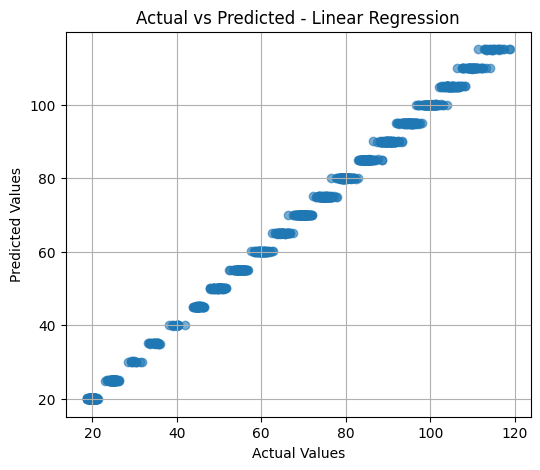

In [6]:
start = time.time()

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

end = time.time()

train_time_lr = round(end - start, 4)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
results = []

results.append(
    evaluate_model(
        y_test,
        y_pred_lr,
        X_test.shape[1],
        "Linear Regression",
        train_time_lr
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_lr, "Linear Regression")

Best Ridge Parameters:
{'alpha': 0.1}

========== Ridge Regression ==========
MAE          : 0.7888181394108579
MSE          : 1.0991779487029778
RMSE         : 1.0484168773455422
R² Score     : 0.9987859412880663
Adjusted R²  : 0.9987595104017397
Training Time: 4.2957 seconds


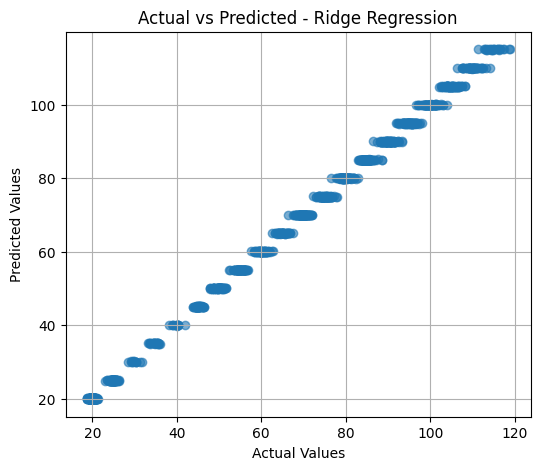

In [7]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train_scaled, y_train)

end = time.time()

best_ridge = grid.best_estimator_

train_time_ridge = round(end - start, 4)

print("Best Ridge Parameters:")
print(grid.best_params_)

# Predictions
y_pred_ridge = best_ridge.predict(X_test_scaled)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_ridge,
        X_test.shape[1],
        "Ridge Regression",
        train_time_ridge
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_ridge, "Ridge Regression")

Best Lasso Parameters:
{'alpha': 0.01}

========== Lasso Regression ==========
MAE          : 0.787677075333439
MSE          : 1.100625435069644
RMSE         : 1.04910697027026
R² Score     : 0.9987843425174251
Adjusted R²  : 0.998757876824771
Training Time: 2.3806 seconds


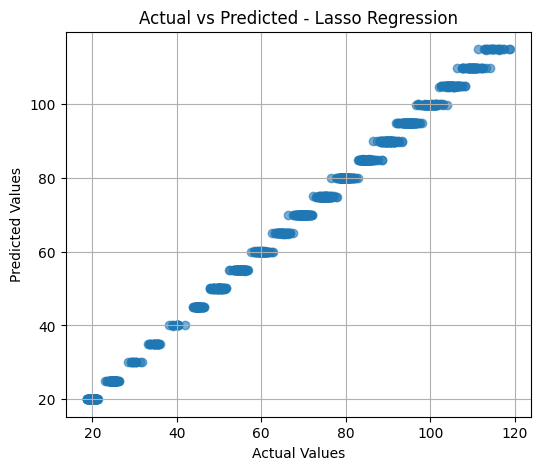

In [8]:
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train_scaled, y_train)

end = time.time()

best_lasso = grid.best_estimator_

train_time_lasso = round(end - start, 4)

print("Best Lasso Parameters:")
print(grid.best_params_)

# Predictions
y_pred_lasso = best_lasso.predict(X_test_scaled)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_lasso,
        X_test.shape[1],
        "Lasso Regression",
        train_time_lasso
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_lasso, "Lasso Regression")

Best ElasticNet Parameters:
{'alpha': 0.01, 'l1_ratio': 0.8}

========== ElasticNet ==========
MAE          : 0.788050795996508
MSE          : 1.0979621790879788
RMSE         : 1.047836904812948
R² Score     : 0.9987872841240417
Adjusted R²  : 0.9987608824721703
Training Time: 15.95 seconds


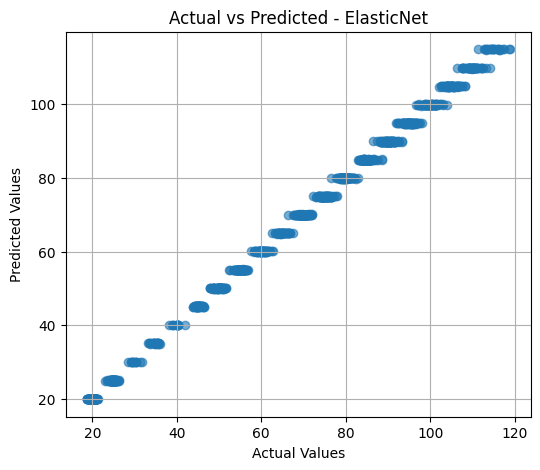

In [9]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.2, 0.5, 0.8]
}

grid = GridSearchCV(
    ElasticNet(max_iter=5000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train_scaled, y_train)

end = time.time()

best_enet = grid.best_estimator_

train_time_enet = round(end - start, 4)

print("Best ElasticNet Parameters:")
print(grid.best_params_)

# Predictions
y_pred_enet = best_enet.predict(X_test_scaled)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_enet,
        X_test.shape[1],
        "ElasticNet",
        train_time_enet
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_enet, "ElasticNet")

Best Decision Tree Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

========== Decision Tree ==========
MAE          : 1.018503835646106
MSE          : 2.164525357430006
RMSE         : 1.471232598004138
R² Score     : 0.9976092489205319
Adjusted R²  : 0.9975572006386857
Training Time: 6.266 seconds


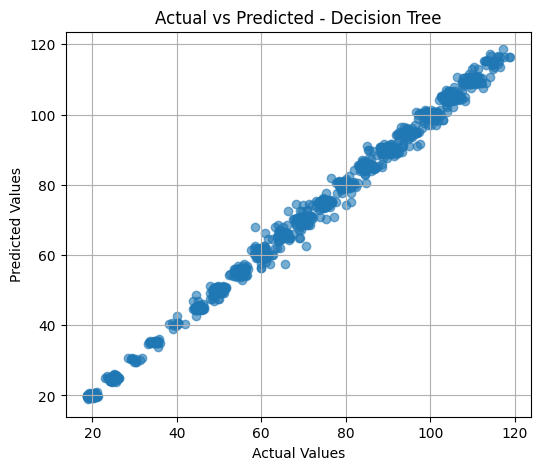

In [10]:
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train, y_train)

end = time.time()

best_dt = grid.best_estimator_

train_time_dt = round(end - start, 4)

print("Best Decision Tree Parameters:")
print(grid.best_params_)

# Predictions
y_pred_dt = best_dt.predict(X_test)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_dt,
        X_test.shape[1],
        "Decision Tree",
        train_time_dt
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_dt, "Decision Tree")

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

========== Random Forest ==========
MAE          : 0.9061706360471796
MSE          : 1.6278762693846625
RMSE         : 1.2758825452935165
R² Score     : 0.9982019859758572
Adjusted R²  : 0.9981628419840398
Training Time: 289.6975 seconds


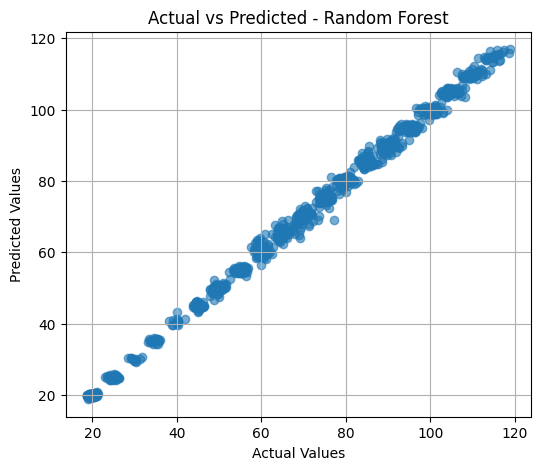

In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train, y_train)

end = time.time()

best_rf = grid.best_estimator_

train_time_rf = round(end - start, 4)

print("Best Random Forest Parameters:")
print(grid.best_params_)

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_rf,
        X_test.shape[1],
        "Random Forest",
        train_time_rf
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_rf, "Random Forest")

Best SVR Parameters:
{'C': 1, 'epsilon': 0.1, 'kernel': 'linear'}

========== SVR ==========
MAE          : 0.7892527615238362
MSE          : 1.0968433942750961
RMSE         : 1.0473029142875026
R² Score     : 0.9987885198388324
Adjusted R²  : 0.998762145089315
Training Time: 336.1394 seconds


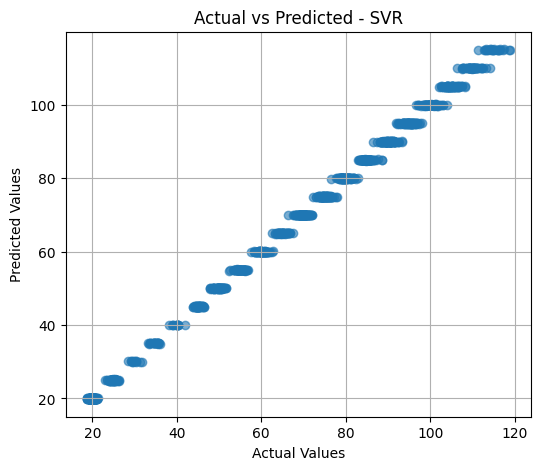

In [13]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'epsilon': [0.1, 0.2, 0.5]
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

start = time.time()

grid.fit(X_train_scaled, y_train)

end = time.time()

best_svr = grid.best_estimator_

train_time_svr = round(end - start, 4)

print("Best SVR Parameters:")
print(grid.best_params_)

# Predictions
y_pred_svr = best_svr.predict(X_test_scaled)

# Evaluation
results.append(
    evaluate_model(
        y_test,
        y_pred_svr,
        X_test.shape[1],
        "SVR",
        train_time_svr
    )
)

# Plot
actual_vs_predicted(y_test, y_pred_svr, "SVR")

In [14]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adj. R²",
        "Training Time"
    ]
)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
)

print(results_df)

               Model       MAE       MSE      RMSE        R²   Adj. R²  \
6                SVR  0.789253  1.096843  1.047303  0.998789  0.998762   
3         ElasticNet  0.788051  1.097962  1.047837  0.998787  0.998761   
1   Ridge Regression  0.788818  1.099178  1.048417  0.998786  0.998760   
0  Linear Regression  0.788819  1.099202  1.048429  0.998786  0.998759   
2   Lasso Regression  0.787677  1.100625  1.049107  0.998784  0.998758   
5      Random Forest  0.906171  1.627876  1.275883  0.998202  0.998163   
4      Decision Tree  1.018504  2.164525  1.471233  0.997609  0.997557   

   Training Time  
6       336.1394  
3        15.9500  
1         4.2957  
0         0.1430  
2         2.3806  
5       289.6975  
4         6.2660  


In [15]:
best_model = results_df.iloc[0]

print("Best Model Selected:")
print(best_model)

print("""
DETAILED JUSTIFICATION

1. The best model was selected using highest R² score,
   which indicates how well the model explains variance
   in MonthlyCharges.

2. Lower MAE and RMSE indicate smaller prediction errors.

3. Adjusted R² was also considered because it penalizes
   unnecessary features.

4. Training time helps compare computational efficiency.

5. The selected model achieved the best balance between:
   - High predictive power
   - Low error
   - Good generalization
   - Reasonable training time
""")

Best Model Selected:
Model                 SVR
MAE              0.789253
MSE              1.096843
RMSE             1.047303
R²               0.998789
Adj. R²          0.998762
Training Time    336.1394
Name: 6, dtype: object

DETAILED JUSTIFICATION

1. The best model was selected using highest R² score,
   which indicates how well the model explains variance
   in MonthlyCharges.

2. Lower MAE and RMSE indicate smaller prediction errors.

3. Adjusted R² was also considered because it penalizes
   unnecessary features.

4. Training time helps compare computational efficiency.

5. The selected model achieved the best balance between:
   - High predictive power
   - Low error
   - Good generalization
   - Reasonable training time



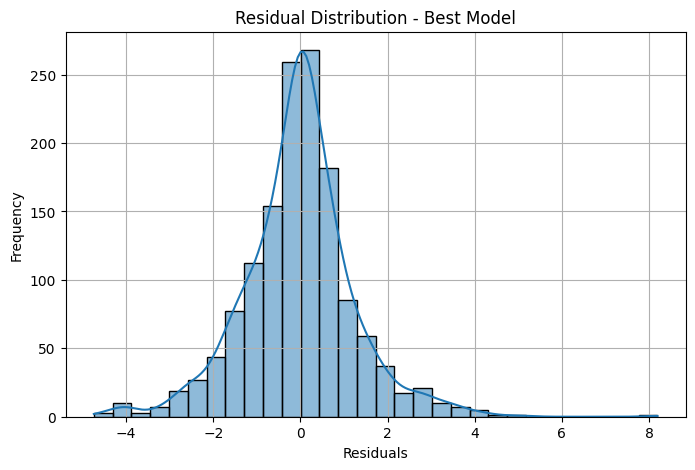


Residual Analysis:

1. If residuals are centered around zero, predictions are unbiased.
2. Bell-shaped residuals suggest approximate normality.
3. Skewness or long tails indicate model misses some patterns.
4. Wide spread means larger prediction errors.



In [16]:
y_pred_best = y_pred_rf
# Residuals
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=30)

plt.title("Residual Distribution - Best Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print("""
Residual Analysis:

1. If residuals are centered around zero, predictions are unbiased.
2. Bell-shaped residuals suggest approximate normality.
3. Skewness or long tails indicate model misses some patterns.
4. Wide spread means larger prediction errors.
""")

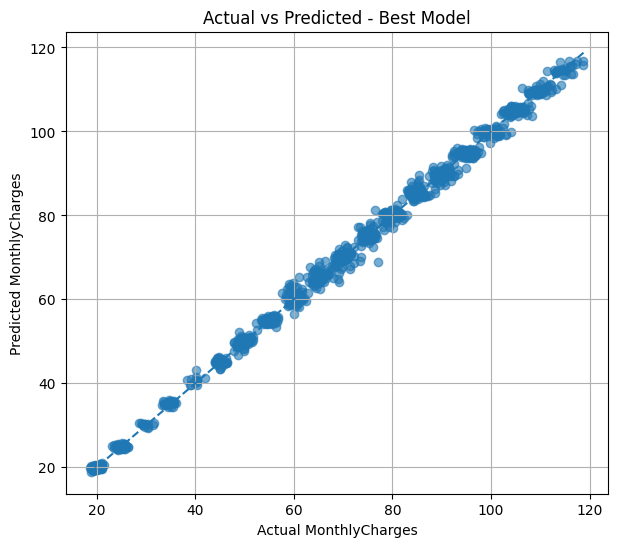


Interpretation:

1. Points close to the diagonal line indicate accurate predictions.
2. Large deviations from the line indicate higher errors.
3. A tighter cluster around the line means better model fit.



In [17]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_best, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")
plt.title("Actual vs Predicted - Best Model")
plt.grid(True)
plt.show()

print("""
Interpretation:

1. Points close to the diagonal line indicate accurate predictions.
2. Large deviations from the line indicate higher errors.
3. A tighter cluster around the line means better model fit.
""")

Top 10 Important Coefficients - Linear Regression
InternetService_Fiber optic       12.361772
StreamingTV_Yes                    4.852460
StreamingMovies_Yes                4.841409
PhoneService_Yes                   2.972279
MultipleLines_No phone service    -2.972279
MultipleLines_Yes                  2.474261
DeviceProtection_Yes               2.371256
OnlineBackup_Yes                   2.365582
TechSupport_Yes                    2.273959
OnlineSecurity_Yes                 2.272373
dtype: float64


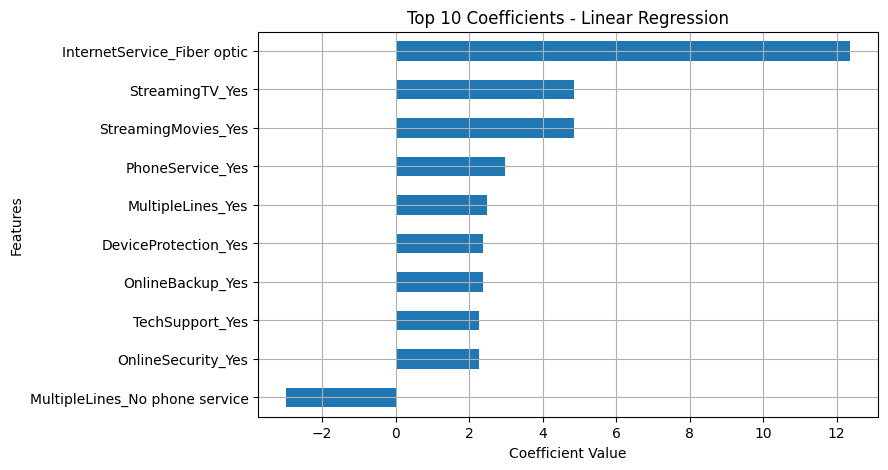


Top 10 Important Coefficients - Ridge
InternetService_Fiber optic       12.361233
StreamingTV_Yes                    4.852342
StreamingMovies_Yes                4.841284
PhoneService_Yes                   2.972277
MultipleLines_No phone service    -2.972277
MultipleLines_Yes                  2.474233
DeviceProtection_Yes               2.371187
OnlineBackup_Yes                   2.365471
TechSupport_Yes                    2.273835
OnlineSecurity_Yes                 2.272229
dtype: float64


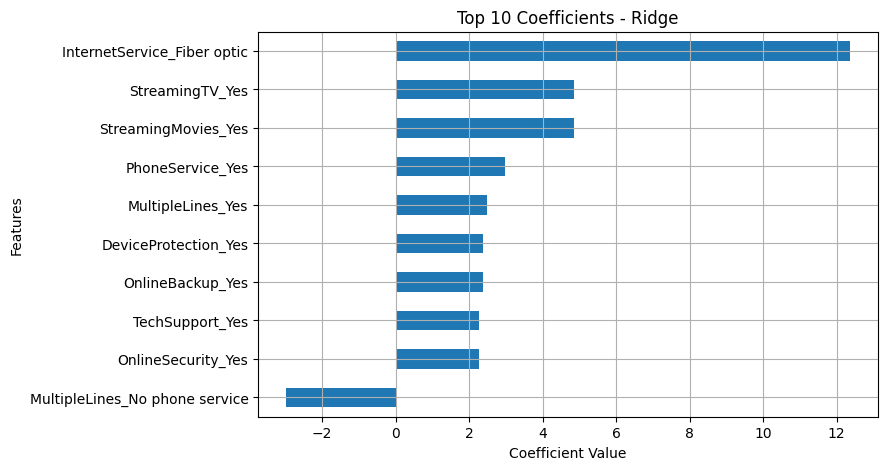


Top 10 Important Coefficients - Lasso
InternetService_Fiber optic    12.373784
InternetService_No            -10.291321
PhoneService_Yes                5.943142
StreamingTV_Yes                 4.853005
StreamingMovies_Yes             4.842970
MultipleLines_Yes               2.468683
DeviceProtection_Yes            2.368578
OnlineBackup_Yes                2.362498
TechSupport_Yes                 2.268586
OnlineSecurity_Yes              2.266097
dtype: float64


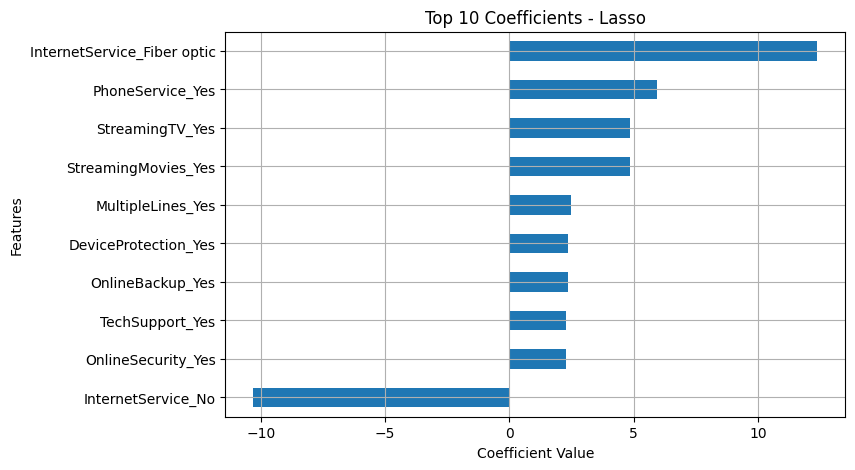


Top 10 Important Coefficients - ElasticNet
InternetService_Fiber optic       12.314375
StreamingTV_Yes                    4.840813
StreamingMovies_Yes                4.828703
PhoneService_Yes                   2.972466
MultipleLines_No phone service    -2.969998
MultipleLines_Yes                  2.468296
DeviceProtection_Yes               2.361647
OnlineBackup_Yes                   2.350750
TechSupport_Yes                    2.254417
OnlineSecurity_Yes                 2.249230
dtype: float64


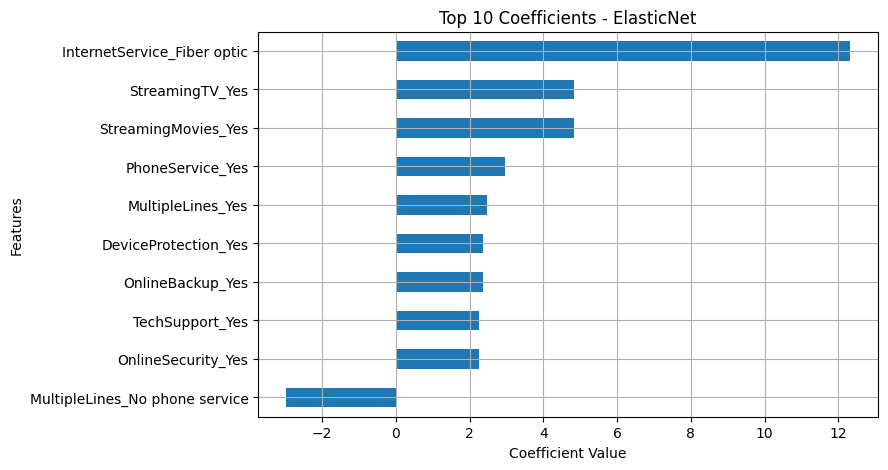

In [18]:
# Linear Regression Coefficients
coef_lr = pd.Series(lr.coef_, index=X.columns)

top_lr = coef_lr.abs().sort_values(ascending=False).head(10)

print("Top 10 Important Coefficients - Linear Regression")
print(coef_lr[top_lr.index])

plt.figure(figsize=(8,5))
coef_lr[top_lr.index].sort_values().plot(kind='barh')

plt.title("Top 10 Coefficients - Linear Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(True)
plt.show()

# Ridge Coefficients
coef_ridge = pd.Series(best_ridge.coef_, index=X.columns)

top_ridge = coef_ridge.abs().sort_values(ascending=False).head(10)

print("\nTop 10 Important Coefficients - Ridge")
print(coef_ridge[top_ridge.index])

plt.figure(figsize=(8,5))
coef_ridge[top_ridge.index].sort_values().plot(kind='barh')

plt.title("Top 10 Coefficients - Ridge")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(True)
plt.show()

# Lasso Coefficients
coef_lasso = pd.Series(best_lasso.coef_, index=X.columns)

top_lasso = coef_lasso.abs().sort_values(ascending=False).head(10)

print("\nTop 10 Important Coefficients - Lasso")
print(coef_lasso[top_lasso.index])

plt.figure(figsize=(8,5))
coef_lasso[top_lasso.index].sort_values().plot(kind='barh')

plt.title("Top 10 Coefficients - Lasso")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(True)
plt.show()

# ElasticNet Coefficients
coef_enet = pd.Series(best_enet.coef_, index=X.columns)

top_enet = coef_enet.abs().sort_values(ascending=False).head(10)

print("\nTop 10 Important Coefficients - ElasticNet")
print(coef_enet[top_enet.index])

plt.figure(figsize=(8,5))
coef_enet[top_enet.index].sort_values().plot(kind='barh')

plt.title("Top 10 Coefficients - ElasticNet")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.grid(True)
plt.show()